# Cifrado de Imágenes para Azure - Prueba de Concepto

Este notebook documenta el proceso de cifrado seguro de imágenes médicas que se subirán a Azure Storage y procesarán en Compute Instances.

## Arquitectura de Seguridad

| Componente | Servicio Azure | Función |
|------------|----------------|---------|
| Gestión de Llaves | **Azure Key Vault** | Almacena llaves de cifrado AES-256 |
| Almacenamiento | **Azure Blob Storage** (Private Endpoint) | Guarda imágenes cifradas |
| Procesamiento | **ML Compute Instance** (VNet) | Descifra y procesa |
| Validación | **Hash SHA-256** | Garantiza integridad |

## Algoritmo de Cifrado

| Propiedad | Valor |
|-----------|-------|
| Algoritmo | **AES-256-GCM** (AEAD) |
| Tamaño de llave | 256 bits (32 bytes) |
| Modo | GCM (Galois/Counter Mode) |
| Nonce | 96 bits (12 bytes, aleatorio por operación) |
| Tag de autenticación | 128 bits (16 bytes) |

## Flujo de Seguridad

```
Hospital Local → Cifrado → Azure Storage → Compute Instance → Descifrado → Procesamiento
     |                |            |              |              |
  [Imagen]  [AES-256-GCM+Nonce] [.enc+nonce]  [Key Vault]  [Validación AEAD+Hash]
```


## 1. Importación de Librerías

Necesitamos:
- **hashlib**: Para calcular hash SHA-256 y validar integridad
- **cryptography.hazmat.primitives.ciphers.aead.AESGCM**: Cifrado AES-256-GCM (AEAD - autenticado)
- **os**: Manejo de archivos, directorios y generación de nonces criptográficos


In [1]:
import os
import hashlib
from cryptography.hazmat.primitives.ciphers.aead import AESGCM


## 2. Configuración de la Llave de Cifrado AES-256

### Entorno Local (Prueba)
Generamos una llave de 32 bytes (256 bits) usando `os.urandom` para simular el flujo.

### Entorno Azure (Producción)
La llave se obtendría de **Azure Key Vault** (almacenada como hex o base64):

```python
from azure.identity import DefaultAzureCredential
from azure.keyvault.secrets import SecretClient
from cryptography.hazmat.primitives.ciphers.aead import AESGCM

credential = DefaultAzureCredential()
client = SecretClient(vault_url="https://mi-kv-fedml.vault.azure.net/", credential=credential)
llave_hex = client.get_secret("encryption-key-aes256").value
llave = bytes.fromhex(llave_hex)   # 32 bytes = 256 bits
cifrador = AESGCM(llave)
```

### Consideraciones de Seguridad
- La llave NUNCA se almacena en código ni en variables de entorno de texto plano
- Se usa Managed Identity para autenticación sin secretos
- Key Vault está en la misma VNet (Private Endpoint)
- Cada operación de cifrado genera un **nonce único** de 12 bytes (96 bits)
- El modo GCM provee autenticación integrada: si el ciphertext es alterado, el descifrado falla


In [2]:
# ENTORNO LOCAL: Generación de llave AES-256 temporal
LLAVE_LOCAL = os.urandom(32)   # 256 bits de entropía criptográfica
cifrador = AESGCM(LLAVE_LOCAL)

print(f"Llave generada (simulación local - AES-256-GCM):")
print(f"Longitud: {len(LLAVE_LOCAL)} bytes ({len(LLAVE_LOCAL) * 8} bits)")
print(f"Modo: GCM (Galois/Counter Mode - AEAD)")
print(f"Tipo: {type(cifrador)}")
print(f"\nEn producción, esta llave vendría de Azure Key Vault (almacenada como hex de 64 chars)")


Llave generada (simulación local - AES-256-GCM):
Longitud: 32 bytes (256 bits)
Modo: GCM (Galois/Counter Mode - AEAD)
Tipo: <class 'cryptography.hazmat.bindings._rust.openssl.aead.AESGCM'>

En producción, esta llave vendría de Azure Key Vault (almacenada como hex de 64 chars)


## 3. Función de Validación de Integridad

El hash SHA-256 garantiza que la imagen no se modifique durante:
- La transmisión a Azure
- El almacenamiento
- El proceso de descifrado

### ¿Por qué SHA-256?
- Genera un "fingerprint" único de 256 bits
- Cualquier cambio mínimo en la imagen produce un hash completamente diferente
- Es computacionalmente imposible generar dos archivos con el mismo hash

### Flujo de Validación
1. Hash original calculado antes de cifrar
2. Hash final calculado después de descifrar
3. Si coinciden → Integridad garantizada ✅

In [3]:
def calcular_hash(ruta_archivo):
    """
    Calcula el hash SHA-256 para validar integridad.
    
    Args:
        ruta_archivo (str): Ruta al archivo a hashear
        
    Returns:
        str: Hash hexadecimal de 64 caracteres
    """
    sha256_hash = hashlib.sha256()
    
    # Lectura en bloques para archivos grandes (eficiente en memoria)
    with open(ruta_archivo, "rb") as f:
        for byte_block in iter(lambda: f.read(4096), b""):
            sha256_hash.update(byte_block)
    
    return sha256_hash.hexdigest()

## 4. Creación de Directorios de Trabajo

Simulamos la estructura de almacenamiento:

| Directorio | Representa | En Azure |
|------------|------------|----------|
| `imagenes_originales/` | Hospital local | On-premises |
| `servidor_simulado/` | Azure Storage | Blob Container (cifrado) |
| `servidor_simulado/recuperada_*` | Compute Instance | Descifrado temporal en VM |

In [4]:
# Crear directorios si no existen
os.makedirs("imagenes_originales", exist_ok=True)
os.makedirs("servidor_simulado", exist_ok=True)

print("✅ Directorios creados:")
print("  - imagenes_originales/ (origen local)")
print("  - servidor_simulado/ (simula Azure Storage)")

✅ Directorios creados:
  - imagenes_originales/ (origen local)
  - servidor_simulado/ (simula Azure Storage)


## 5. Funcion Principal: Flujo de Cifrado Seguro AES-256-GCM

Esta funcion simula todo el ciclo de vida de una imagen medica desde el hospital hasta Azure.

### Fases del Proceso

#### FASE A: Cifrado y "Subida" a Azure
1. Leer imagen original
2. Calcular hash SHA-256 de integridad
3. Generar nonce de 12 bytes aleatorios (`os.urandom`)
4. Cifrar con AES-256-GCM (incluye tag de autenticacion de 16 bytes)
5. Guardar formato: `[nonce 12B] + [ciphertext + tag 16B]`
6. "Subir" a Azure Storage (simulado con archivo .enc)

#### FASE B: Descifrado en Compute Instance
1. Recuperar llave de Key Vault
2. Descargar imagen cifrada de Storage
3. Separar nonce (primeros 12 bytes) del ciphertext
4. Descifrar y **autenticar** con AES-256-GCM (falla si fue alterado)

#### FASE C: Validacion de Integridad
1. Calcular hash SHA-256 de imagen descifrada
2. Comparar con hash original
3. Si coinciden -> Identidad bit a bit garantizada
4. Si difieren -> RECHAZAR (anomalia grave)

### Formato del archivo .enc
```
+-------------+--------------------------------------+
| nonce 12B   | ciphertext + GCM tag 16B             |
+-------------+--------------------------------------+
  os.urandom    AES-256-GCM.encrypt(nonce, plaintext)
```


In [5]:
NONCE_SIZE = 12  # 96 bits recomendado para AES-GCM

def simular_flujo_seguro(nombre_imagen, carpeta_origen="imagenes_originales", carpeta_destino="servidor_simulado"):
    """
    Simula el flujo completo de cifrado/descifrado AES-256-GCM con validacion de integridad.

    Formato del archivo .enc:
        [12 bytes nonce] + [ciphertext + 16 bytes GCM tag]

    Args:
        nombre_imagen (str): Nombre del archivo a procesar
        carpeta_origen (str): Directorio donde se encuentra la imagen original
        carpeta_destino (str): Directorio donde se guardara el archivo cifrado y recuperado
    
    Returns:
        tuple: (ruta_original, ruta_recuperada) para uso posterior (SSIM, visualizacion)
    """
    ruta_origen  = f"{carpeta_origen}/{nombre_imagen}"
    ruta_destino = f"{carpeta_destino}/{nombre_imagen}.enc"
    ruta_final   = f"{carpeta_destino}/recuperada_{nombre_imagen}"

    print(f"\n{'='*60}")
    print(f"INICIANDO FLUJO SEGURO AES-256-GCM: {nombre_imagen}")
    print(f"Origen : {ruta_origen}")
    print(f"Destino: {ruta_destino}")
    print(f"{'='*60}\n")

    # ==================== PASO A: CIFRADO ====================
    print("PASO A: Cifrado AES-256-GCM y subida a Azure Storage")
    print("-" * 60)

    hash_original = calcular_hash(ruta_origen)
    print(f"   Hash original: {hash_original[:16]}...")

    with open(ruta_origen, "rb") as f:
        datos_originales = f.read()

    # Nonce unico por operacion (CRITICO: nunca reutilizar nonce con la misma llave)
    nonce = os.urandom(NONCE_SIZE)
    ciphertext = cifrador.encrypt(nonce, datos_originales, None)

    # Guardar: nonce (12 bytes) + ciphertext+tag (len(datos)+16 bytes)
    os.makedirs(carpeta_destino, exist_ok=True)
    with open(ruta_destino, "wb") as f:
        f.write(nonce + ciphertext)

    tamano_original = os.path.getsize(ruta_origen)
    tamano_cifrado  = os.path.getsize(ruta_destino)
    overhead = tamano_cifrado - tamano_original

    print(f"   Tamanio original: {tamano_original:,} bytes")
    print(f"   Tamanio cifrado:  {tamano_cifrado:,} bytes")
    print(f"   Overhead:         {overhead} bytes  (12 nonce + 16 GCM tag = 28 bytes)")
    print(f"   Cifrado y guardado con exito\n")

    # ==================== PASO B: DESCIFRADO ====================
    print("PASO B: Descifrado AES-256-GCM en Compute Instance (Azure)")
    print("-" * 60)

    with open(ruta_destino, "rb") as f:
        blob = f.read()

    nonce_leido      = blob[:NONCE_SIZE]
    ciphertext_leido = blob[NONCE_SIZE:]

    # Si el ciphertext fue alterado, AESGCM lanza InvalidTag (autenticacion integrada)
    datos_desencriptados = cifrador.decrypt(nonce_leido, ciphertext_leido, None)

    with open(ruta_final, "wb") as f:
        f.write(datos_desencriptados)

    print(f"   Imagen descifrada y autenticada correctamente (GCM tag OK)\n")

    # ==================== PASO C: VALIDACION ====================
    print("PASO C: Validacion de Integridad SHA-256")
    print("-" * 60)

    hash_final = calcular_hash(ruta_final)
    print(f"   Hash original: {hash_original}")
    print(f"   Hash final:    {hash_final}")

    if hash_original == hash_final:
        print(f"\n   EXITO: Los hashes coinciden")
        print(f"   La imagen es identica tras el proceso")
        print(f"   Listo para procesamiento con modelo FL")
    else:
        print(f"\n   ERROR: La integridad de la imagen se perdio")
        print(f"   Posible corrupcion o ataque")
        print(f"   RECHAZAR imagen")

    print(f"\n{'='*60}\n")
    return ruta_origen, ruta_final


## 6. Prueba con Imagen de Ejemplo

Antes de ejecutar, asegúrate de tener una imagen llamada `test.jpg` en el directorio `imagenes_originales/`.

Si no tienes una, puedes:
1. Copiar cualquier imagen al directorio
2. Renombrarla a `test.jpg`
3. O ejecutar: `curl -o imagenes_originales/test.jpg https://via.placeholder.com/600`

In [6]:
# Verificar si existe la imagen de prueba
if os.path.exists("imagenes_originales/test.jpg"):
    simular_flujo_seguro("test.jpg")
else:
    print("⚠️ No se encontró 'test.jpg'")
    print("\nPor favor:")
    print("1. Coloca una imagen en 'imagenes_originales/'")
    print("2. Renómbrala a 'test.jpg'")
    print("3. Ejecuta esta celda nuevamente")


INICIANDO FLUJO SEGURO AES-256-GCM: test.jpg
Origen : imagenes_originales/test.jpg
Destino: servidor_simulado/test.jpg.enc

PASO A: Cifrado AES-256-GCM y subida a Azure Storage
------------------------------------------------------------
   Hash original: 8590d40422839763...
   Tamanio original: 55,356 bytes
   Tamanio cifrado:  55,384 bytes
   Overhead:         28 bytes  (12 nonce + 16 GCM tag = 28 bytes)
   Cifrado y guardado con exito

PASO B: Descifrado AES-256-GCM en Compute Instance (Azure)
------------------------------------------------------------
   Imagen descifrada y autenticada correctamente (GCM tag OK)

PASO C: Validacion de Integridad SHA-256
------------------------------------------------------------
   Hash original: 8590d40422839763941a3695ecd077b8016c8a252f5c7b000fcddd8647577064
   Hash final:    8590d40422839763941a3695ecd077b8016c8a252f5c7b000fcddd8647577064

   EXITO: Los hashes coinciden
   La imagen es identica tras el proceso
   Listo para procesamiento con 

## 7. Verificación de Archivos Generados

Revisemos los archivos creados durante el proceso.

In [7]:
print("📁 Estructura de directorios generada:\n")

if os.path.exists("imagenes_originales"):
    print("imagenes_originales/")
    for archivo in os.listdir("imagenes_originales"):
        tamano = os.path.getsize(f"imagenes_originales/{archivo}")
        print(f"  └─ {archivo} ({tamano:,} bytes)")

if os.path.exists("servidor_simulado"):
    print("\nservidor_simulado/ (simula Azure Storage)")
    for archivo in os.listdir("servidor_simulado"):
        tamano = os.path.getsize(f"servidor_simulado/{archivo}")
        tipo = "cifrado" if archivo.endswith(".enc") else "descifrado"
        print(f"  └─ {archivo} ({tamano:,} bytes) - {tipo}")

📁 Estructura de directorios generada:

imagenes_originales/
  └─ test.JPG (55,356 bytes)

servidor_simulado/ (simula Azure Storage)
  └─ img_test.dcm.enc (9,828,586 bytes) - cifrado
  └─ recuperada_img_test.dcm (9,828,558 bytes) - descifrado
  └─ recuperada_test.jpg (55,356 bytes) - descifrado
  └─ test.jpg.enc (55,384 bytes) - cifrado


## 7.1 Validación Estructural: SSIM (Structural Similarity Index)

En el ámbito médico (como en procesamientos con **NVFLARE**), además de validar el hash a nivel de bits, se verifica la similitud estructural de los pixeles tras recuperar la imagen (**SSIM**). 

Un valor SSIM de `1.0` garantiza que la imagen recuperada es perceptualmente y estructuralmente idéntica a la original, evitando el riesgo de pérdida de calidad o alteración que podría llevar a diagnósticos erróneos.

In [8]:
# Necesitarás OpenCV y scikit-image. Descomenta la siguiente línea si necesitas instalarlos:
# !pip install opencv-python-headless scikit-image numpy

import cv2
from skimage.metrics import structural_similarity as ssim
import os

nombre_imagen = "test.jpg"
ruta_original = f"imagenes_originales/{nombre_imagen}"
ruta_recuperada = f"servidor_simulado/recuperada_{nombre_imagen}"

if os.path.exists(ruta_original) and os.path.exists(ruta_recuperada):
    # Leer imágenes en escala de grises para un cálculo SSIM más eficiente y estándar
    img_orig = cv2.imread(ruta_original, cv2.IMREAD_GRAYSCALE)
    img_recup = cv2.imread(ruta_recuperada, cv2.IMREAD_GRAYSCALE)
    
    if img_orig is not None and img_recup is not None:
        # Calcular SSIM
        score, diff = ssim(img_orig, img_recup, full=True)
        
        print(f"📊 Índice de Similitud Estructural (SSIM): {score:.6f}")
        print(f"   (Rango: -1 a 1, donde 1.0 significa idénticas)\n")
        
        if score >= 0.9999:
            print("✅ ÉXITO: Las imágenes son estructuralmente idénticas.")
            print("✅ La encriptación/desencriptación es segura para uso médico (Lossless).")
        else:
            print("⚠️ ADVERTENCIA: Se detectaron cambios estructurales en la imagen.")
    else:
        print("❌ Error: No se pudieron procesar las imágenes como matriz de píxeles.")
else:
    print("⚠️ Advertencia: No se encontraron las imágenes para comparar.")

📊 Índice de Similitud Estructural (SSIM): 1.000000
   (Rango: -1 a 1, donde 1.0 significa idénticas)

✅ ÉXITO: Las imágenes son estructuralmente idénticas.
✅ La encriptación/desencriptación es segura para uso médico (Lossless).


## 8. Prueba con Imagen DICOM Real (img_test.dcm)

Las imágenes médicas usan el estándar **DICOM** (Digital Imaging and Communications in Medicine).  
A diferencia de JPEG/PNG, los archivos `.dcm` contienen:

| Componente | Descripcion |
|------------|-------------|
| **Header DICOM** | Metadatos del paciente, modalidad, fecha, equipo |
| **Pixel Data** | Array de pixeles (tipicamente uint16, no uint8) |
| **Transfer Syntax** | Compresion/codificacion (JPEG, RLE, raw) |

### Flujo aplicado a DICOM
1. Instalar `pydicom` para leer/escribir archivos DICOM
2. Inspeccionar metadatos del archivo original
3. Cifrar el archivo `.dcm` completo (binario) con AES-256-GCM
4. Descifrar y recuperar el `.dcm` bit a bit
5. Validar integridad: SHA-256 + SSIM sobre el pixel array

> La imagen origen está en `servidor_local/img_test.dcm`  
> Los archivos cifrado y recuperado se guardarán en `servidor_simulado/`


In [9]:
# Instalacion de librerias necesarias
%pip install pydicom matplotlib scikit-image cryptography --quiet
print("Librerias instaladas correctamente.")


Note: you may need to restart the kernel to use updated packages.
Librerias instaladas correctamente.


In [10]:
import pydicom

RUTA_DCM_ORIGEN = "servidor_local/img_test.dcm"

ds = pydicom.dcmread(RUTA_DCM_ORIGEN)

print("="*60)
print("METADATOS DICOM: img_test.dcm")
print("="*60)

# Atributos clave (con getattr para evitar error si no existen)
campos = [
    ("Modalidad",           "Modality"),
    ("Descripcion serie",   "SeriesDescription"),
    ("Descripcion estudio", "StudyDescription"),
    ("Fabricante equipo",   "Manufacturer"),
    ("Fecha adquisicion",   "AcquisitionDate"),
    ("Transfer Syntax UID", "file_meta.TransferSyntaxUID"),
    ("Columnas (ancho)",    "Columns"),
    ("Filas (alto)",        "Rows"),
    ("Bits almacenados",    "BitsStored"),
    ("Bits asignados",      "BitsAllocated"),
    ("Pixel Representation","PixelRepresentation"),
    ("Photometric Interp",  "PhotometricInterpretation"),
]

for etiqueta, atributo in campos:
    try:
        partes = atributo.split(".")
        valor = ds
        for parte in partes:
            valor = getattr(valor, parte, "N/A")
        print(f"  {etiqueta:<22}: {valor}")
    except Exception:
        print(f"  {etiqueta:<22}: N/A")

print(f"\n  Tamanio del archivo   : {os.path.getsize(RUTA_DCM_ORIGEN):,} bytes")

if hasattr(ds, "pixel_array"):
    arr = ds.pixel_array
    print(f"  Shape pixel array     : {arr.shape}")
    print(f"  dtype pixel array     : {arr.dtype}")
    print(f"  Valor minimo pixel    : {arr.min()}")
    print(f"  Valor maximo pixel    : {arr.max()}")


METADATOS DICOM: img_test.dcm
  Modalidad             : MG
  Descripcion serie     : R CC C-View
  Descripcion estudio   : Standard Screening - TomoHD
  Fabricante equipo     : HOLOGIC, Inc.
  Fecha adquisicion     : N/A
  Transfer Syntax UID   : 1.2.840.10008.1.2.1
  Columnas (ancho)      : 1996
  Filas (alto)          : 2457
  Bits almacenados      : 10
  Bits asignados        : 16
  Pixel Representation  : 0
  Photometric Interp    : MONOCHROME2

  Tamanio del archivo   : 9,828,558 bytes
  Shape pixel array     : (2457, 1996)
  dtype pixel array     : uint16
  Valor minimo pixel    : 0
  Valor maximo pixel    : 1023


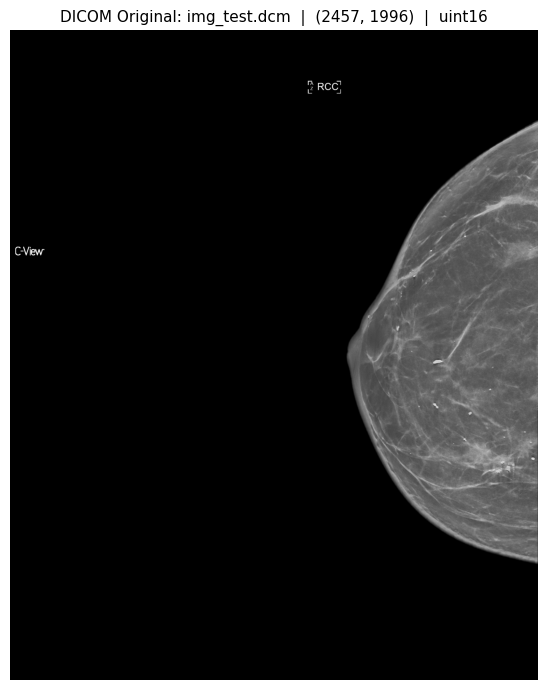

Imagen DICOM visualizada correctamente.


In [11]:
import matplotlib.pyplot as plt
import numpy as np

ds = pydicom.dcmread(RUTA_DCM_ORIGEN)
pixel_array = ds.pixel_array

# Normalizar a uint8 para visualizacion (DICOM suele ser uint16)
pmin, pmax = pixel_array.min(), pixel_array.max()
img_norm = ((pixel_array - pmin) / (pmax - pmin + 1e-8) * 255).astype(np.uint8)

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(img_norm, cmap="gray")
ax.set_title(f"DICOM Original: img_test.dcm  |  {pixel_array.shape}  |  {pixel_array.dtype}", fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.show()
print(f"Imagen DICOM visualizada correctamente.")


In [12]:
# Ejecutar el flujo completo AES-256-GCM sobre la imagen DICOM
ruta_orig_dcm, ruta_recup_dcm = simular_flujo_seguro(
    nombre_imagen   = "img_test.dcm",
    carpeta_origen  = "servidor_local",
    carpeta_destino = "servidor_simulado"
)
print(f"Archivo original  : {ruta_orig_dcm}")
print(f"Archivo recuperado: {ruta_recup_dcm}")



INICIANDO FLUJO SEGURO AES-256-GCM: img_test.dcm
Origen : servidor_local/img_test.dcm
Destino: servidor_simulado/img_test.dcm.enc

PASO A: Cifrado AES-256-GCM y subida a Azure Storage
------------------------------------------------------------
   Hash original: 97f3da94a237344f...
   Tamanio original: 9,828,558 bytes
   Tamanio cifrado:  9,828,586 bytes
   Overhead:         28 bytes  (12 nonce + 16 GCM tag = 28 bytes)
   Cifrado y guardado con exito

PASO B: Descifrado AES-256-GCM en Compute Instance (Azure)
------------------------------------------------------------
   Imagen descifrada y autenticada correctamente (GCM tag OK)

PASO C: Validacion de Integridad SHA-256
------------------------------------------------------------
   Hash original: 97f3da94a237344fb5183ffb1e78bdc06dab38837978ae26ec088fb59bf0ed75
   Hash final:    97f3da94a237344fb5183ffb1e78bdc06dab38837978ae26ec088fb59bf0ed75

   EXITO: Los hashes coinciden
   La imagen es identica tras el proceso
   Listo para proce

VALIDACION SSIM - IMAGEN DICOM
  Archivo original  : servidor_local/img_test.dcm
  Archivo recuperado: servidor_simulado/recuperada_img_test.dcm
  Shape             : (2457, 1996)  |  dtype: uint16
  Data range        : 1023
  SSIM Score        : 1.00000000

  EXITO: SSIM = 1.00000000 - Imagen DICOM identica bit a bit
  Cifrado AES-256-GCM es Lossless - Apto para diagnostico medico


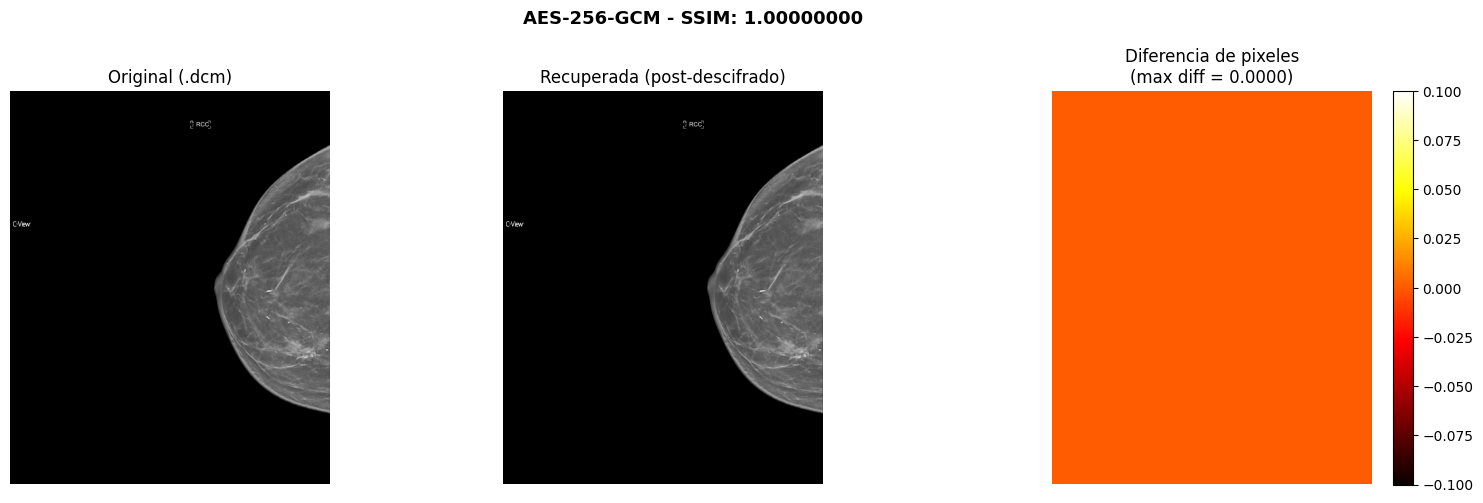

In [13]:
from skimage.metrics import structural_similarity as ssim
import numpy as np
import matplotlib.pyplot as plt
import pydicom

# Leer pixel arrays de ambos archivos DICOM
ds_orig  = pydicom.dcmread(ruta_orig_dcm)
ds_recup = pydicom.dcmread(ruta_recup_dcm)

arr_orig  = ds_orig.pixel_array.astype(np.float32)
arr_recup = ds_recup.pixel_array.astype(np.float32)

# SSIM requiere data_range acorde al tipo de dato DICOM (uint16 -> 65535)
data_range = float(arr_orig.max() - arr_orig.min()) if arr_orig.max() > arr_orig.min() else 1.0

score, diff_map = ssim(arr_orig, arr_recup, full=True, data_range=data_range)

print(f"{'='*60}")
print(f"VALIDACION SSIM - IMAGEN DICOM")
print(f"{'='*60}")
print(f"  Archivo original  : {ruta_orig_dcm}")
print(f"  Archivo recuperado: {ruta_recup_dcm}")
print(f"  Shape             : {arr_orig.shape}  |  dtype: {ds_orig.pixel_array.dtype}")
print(f"  Data range        : {data_range:.0f}")
print(f"  SSIM Score        : {score:.8f}")

if score >= 0.9999:
    print(f"\n  EXITO: SSIM = {score:.8f} - Imagen DICOM identica bit a bit")
    print(f"  Cifrado AES-256-GCM es Lossless - Apto para diagnostico medico")
else:
    print(f"\n  ADVERTENCIA: SSIM = {score:.6f} - Se detectaron diferencias")

# Visualizacion comparativa: original | recuperada | diferencia
def norm_u8(arr):
    mn, mx = arr.min(), arr.max()
    return ((arr - mn) / (mx - mn + 1e-8) * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(norm_u8(arr_orig),  cmap="gray")
axes[0].set_title("Original (.dcm)", fontsize=12)
axes[0].axis("off")

axes[1].imshow(norm_u8(arr_recup), cmap="gray")
axes[1].set_title("Recuperada (post-descifrado)", fontsize=12)
axes[1].axis("off")

diff_vis = np.abs(arr_orig - arr_recup)
im = axes[2].imshow(diff_vis, cmap="hot")
axes[2].set_title(f"Diferencia de pixeles\n(max diff = {diff_vis.max():.4f})", fontsize=12)
axes[2].axis("off")
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle(f"AES-256-GCM - SSIM: {score:.8f}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 8. Arquitectura Propuesta
![Diagrama de arquitectura](./ArquitecturaPropuesta.png)